<a href="https://colab.research.google.com/github/ananyabatra04/fairness-graph-gnn/blob/main/4_GCN_Models_fair_contrastive_updated.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================================================
# Cell 1: path + setup + data + helpers
# =========================================================

!pip -q install torch-geometric pandas numpy scikit-learn

from google.colab import drive
drive.mount('/content/drive')

import os
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

from collections import Counter
from IPython.display import display

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import spearmanr

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv


# -------------------------
# basic config
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEEDS = list(range(10))
print("Device:", device)
print("Seeds :", SEEDS)

BASE_DIR = "/content/drive/MyDrive/courses/network/project/dataset"

DATASETS = {
    "nba": {
        "csv": os.path.join(BASE_DIR, "nba", "nba.csv"),
        "edge": os.path.join(BASE_DIR, "nba", "nba_relationship.txt"),
    },
    "pokec_z": {
        "csv": os.path.join(BASE_DIR, "pokec", "region_job.csv"),
        "edge": os.path.join(BASE_DIR, "pokec", "region_job_relationship.txt"),
    }
}

TASK_CONFIG = {
    "nba": {
        "id_col": "user_id",
        "label_col": "SALARY",
        "sens_col": "country",
    },
    "pokec_z": {
        "id_col": "user_id",
        "label_col": "I_am_working_in_field",
        "sens_col": "region",
    }
}

RUN_CONFIG = {
    "nba": {
        "hidden_dim": 128,
        "repr_dim": 128,
        "proj_dim": 64,
        "dropout": 0.6,            # encoder dropout
        "lr": 0.01,
        "weight_decay": 5e-4,
        "epochs": 300,
        "patience": 50,

        # contrastive
        "pretrain_epochs": 200,
        "pretrain_lr": 1e-3,
        "edge_drop_prob": 0.2,     # random edge drop in fair contrastive pretrain
        "view1_feat_mask_prob": 0.3,
        "view2_feat_mask_prob": 0.4,
        "temperature": 0.5,        # tau
        "lambda_cl_fair": 1.0,
        "contrast_batch_size": 512,

        # fairdrop
        "fair_keep_same": 0.5,     # drop 50% edge from same group
        "fair_keep_diff": 1.0,     # no drop on edge between groups
    },
    "pokec_z": {
        "hidden_dim": 128,
        "repr_dim": 128,
        "proj_dim": 64,
        "dropout": 0.6,
        "lr": 0.01,
        "weight_decay": 5e-4,
        "epochs": 300,
        "patience": 50,

        # contrastive
        "pretrain_epochs": 200,
        "pretrain_lr": 1e-3,
        "edge_drop_prob": 0.2,
        "view1_feat_mask_prob": 0.3,
        "view2_feat_mask_prob": 0.4,
        "temperature": 0.5,
        "lambda_cl_fair": 1.0,
        "contrast_batch_size": 2048,

        # fairdrop
        "fair_keep_same": 0.5,
        "fair_keep_diff": 1.0,
    }
}

SAVE_DIR = os.path.join(BASE_DIR, "results_gcn_4models")
os.makedirs(SAVE_DIR, exist_ok=True)

for ds_name, paths in DATASETS.items():
    print(f"\n[{ds_name}]")
    for k, v in paths.items():
        print(f"  {k}: {v} | exists={os.path.exists(v)}")


# -------------------------
# utilities
# -------------------------
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def read_raw_edges(edge_path):
    edges = []
    with open(edge_path, "r", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            if "," in line:
                parts = line.split(",")
            elif "\t" in line:
                parts = line.split("\t")
            else:
                parts = line.split()

            if len(parts) < 2:
                continue

            try:
                u = int(parts[0])
                v = int(parts[1])
                edges.append((u, v))
            except:
                continue
    return edges


def build_graph_from_raw_csv(csv_path, edge_path, id_col, label_col, sens_col, name="dataset"):

    df = pd.read_csv(csv_path).copy()
    raw_edges = read_raw_edges(edge_path)

    if id_col not in df.columns or label_col not in df.columns or sens_col not in df.columns:
        raise ValueError(f"{name}: check id/label/sens column names")

    df = df.drop_duplicates(subset=[id_col]).copy()

    df = df[df[label_col].isin([0, 1]) & df[sens_col].isin([0, 1])].copy()

    edge_nodes = set()
    for u, v in raw_edges:
        edge_nodes.add(u)
        edge_nodes.add(v)

    common_nodes = sorted(set(df[id_col]) & edge_nodes)
    df = df[df[id_col].isin(common_nodes)].copy()
    df = df.set_index(id_col).loc[common_nodes]

    feature_df = df.drop(columns=[label_col, sens_col]).copy()

    # object/categorical -> one-hot
    cat_cols = feature_df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    if len(cat_cols) > 0:
        feature_df = pd.get_dummies(feature_df, columns=cat_cols, dummy_na=True)

    feature_df = feature_df.replace([np.inf, -np.inf], np.nan).fillna(0)

    for c in feature_df.columns:
        feature_df[c] = pd.to_numeric(feature_df[c], errors="coerce")
    feature_df = feature_df.fillna(0).astype(np.float32)

    node_map = {nid: i for i, nid in enumerate(common_nodes)}

    remapped_edges = []
    for u, v in raw_edges:
        if u in node_map and v in node_map and u != v:
            remapped_edges.append((node_map[u], node_map[v]))

    # undirected + deduplicate
    remapped_edges = remapped_edges + [(v, u) for u, v in remapped_edges]
    remapped_edges = sorted(set(remapped_edges))

    edge_index = torch.tensor(remapped_edges, dtype=torch.long).t().contiguous()
    x = torch.tensor(feature_df.values, dtype=torch.float32)
    y = torch.tensor(df[label_col].values, dtype=torch.long)
    s = torch.tensor(df[sens_col].values, dtype=torch.long)

    data = Data(x=x, edge_index=edge_index, y=y)
    data.s = s
    data.node_ids = torch.tensor(common_nodes, dtype=torch.long)

    print(f"\n===== {name} =====")
    print("num_nodes:", data.num_nodes)
    print("num_edges:", data.edge_index.shape[1])
    print("x shape  :", tuple(data.x.shape))
    print("y dist   :", Counter(data.y.tolist()))
    print("s dist   :", Counter(data.s.tolist()))

    return data


def create_masks_70_15_15(y, seed):
    """
    stratified split:
    train = 70%
    val   = 15%
    test  = 15%
    """
    idx = np.arange(len(y))

    train_idx, temp_idx = train_test_split(
        idx,
        train_size=0.70,
        random_state=seed,
        stratify=y
    )

    temp_y = y[temp_idx]
    val_rel, test_rel = train_test_split(
        np.arange(len(temp_idx)),
        train_size=0.50,
        random_state=seed,
        stratify=temp_y
    )

    val_idx = temp_idx[val_rel]
    test_idx = temp_idx[test_rel]

    train_mask = torch.zeros(len(y), dtype=torch.bool)
    val_mask = torch.zeros(len(y), dtype=torch.bool)
    test_mask = torch.zeros(len(y), dtype=torch.bool)

    train_mask[train_idx] = True
    val_mask[val_idx] = True
    test_mask[test_idx] = True

    return train_mask, val_mask, test_mask


# -------------------------
# fairness metrics
# -------------------------
def statistical_parity(pred, sens):
    """
    | P(\hat{Y}=1 | S=0) - P(\hat{Y}=1 | S=1) |
    """
    pred = np.asarray(pred)
    sens = np.asarray(sens)

    mask0 = sens == 0
    mask1 = sens == 1

    if mask0.sum() == 0 or mask1.sum() == 0:
        return np.nan

    p0 = pred[mask0].mean()
    p1 = pred[mask1].mean()
    return abs(p0 - p1)


def equal_opportunity(pred, y_true, sens):
    """
    | TPR(S=0) - TPR(S=1) |
    """
    pred = np.asarray(pred)
    y_true = np.asarray(y_true)
    sens = np.asarray(sens)

    mask0 = (sens == 0) & (y_true == 1)
    mask1 = (sens == 1) & (y_true == 1)

    if mask0.sum() == 0 or mask1.sum() == 0:
        return np.nan

    tpr0 = pred[mask0].mean()
    tpr1 = pred[mask1].mean()
    return abs(tpr0 - tpr1)


# -------------------------
# edge augmentation
# -------------------------
def get_undirected_pairs(edge_index):
    row, col = edge_index
    mask = row < col
    pairs = edge_index[:, mask]
    if pairs.numel() == 0:
        return edge_index
    return pairs


def make_bidirectional(pairs):
    rev = pairs[[1, 0], :]
    return torch.cat([pairs, rev], dim=1).contiguous()


def random_edge_drop(edge_index, keep_prob=0.8):
    pairs = get_undirected_pairs(edge_index)
    if pairs.numel() == 0:
        return edge_index

    mask = torch.rand(pairs.size(1), device=edge_index.device) < keep_prob
    if mask.sum() == 0:
        mask[torch.randint(0, pairs.size(1), (1,), device=edge_index.device)] = True

    return make_bidirectional(pairs[:, mask])


def fairdrop_edge_drop(edge_index, sens, keep_prob_same=0.5, keep_prob_diff=1.0):

    pairs = get_undirected_pairs(edge_index)
    if pairs.numel() == 0:
        return edge_index

    row, col = pairs
    same_group = (sens[row] == sens[col])

    probs = torch.where(
        same_group,
        torch.full((pairs.size(1),), keep_prob_same, device=edge_index.device),
        torch.full((pairs.size(1),), keep_prob_diff, device=edge_index.device),
    )

    mask = torch.rand(pairs.size(1), device=edge_index.device) < probs
    if mask.sum() == 0:
        mask[torch.randint(0, pairs.size(1), (1,), device=edge_index.device)] = True

    return make_bidirectional(pairs[:, mask])


def feature_mask(x, mask_prob=0.2):
    """Legacy random entry-wise feature masking."""
    keep = (torch.rand_like(x) > mask_prob).float()
    return x * keep


def compute_spearman_feature_scores(x, sens):
    """
    Compute absolute Spearman correlation between each feature column and the
    sensitive attribute, then normalize scores to [0, 1].
    """
    x_np = x.detach().cpu().numpy()
    s_np = sens.detach().cpu().numpy()

    scores = []
    sens_std = np.std(s_np)

    for j in range(x_np.shape[1]):
        col = x_np[:, j]
        if np.std(col) < 1e-12 or sens_std < 1e-12:
            corr = 0.0
        else:
            corr, _ = spearmanr(col, s_np)
            if np.isnan(corr):
                corr = 0.0
        scores.append(abs(float(corr)))

    scores = np.asarray(scores, dtype=np.float32)
    if scores.max() > 0:
        scores = scores / scores.max()

    return torch.tensor(scores, dtype=x.dtype, device=x.device)


def fair_feature_mask(x, feature_scores, base_mask_prob=0.3, max_mask_prob=0.95):
    """
    Fairness-aware column-wise feature masking.
    Features more correlated with the sensitive attribute are more likely to be dropped.
    The expected masking strength is controlled by base_mask_prob.
    """
    if feature_scores.numel() != x.size(1):
        raise ValueError("feature_scores length must match number of feature columns")

    scores = feature_scores.clamp(min=0)

    if torch.all(scores == 0):
        mask_probs = torch.full(
            (x.size(1),),
            fill_value=base_mask_prob,
            dtype=x.dtype,
            device=x.device
        )
    else:
        scaled_scores = scores / scores.mean().clamp_min(1e-12)
        mask_probs = (base_mask_prob * scaled_scores).clamp(0.0, max_mask_prob)

    keep_cols = (torch.rand(x.size(1), device=x.device) > mask_probs).float()
    return x * keep_cols.unsqueeze(0)


# -------------------------
# models
# -------------------------
class GCNEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, repr_dim=64, dropout=0.6):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, repr_dim)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x


class GCNClassifier(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, repr_dim=64, num_classes=2, dropout=0.6):
        super().__init__()
        self.encoder = GCNEncoder(in_dim, hidden_dim, repr_dim, dropout)
        self.classifier = nn.Linear(repr_dim, num_classes)

    def forward(self, x, edge_index):
        z = self.encoder(x, edge_index)
        logits = self.classifier(F.relu(z))
        return logits, z


class ProjectionHead(nn.Module):
    def __init__(self, in_dim, proj_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, proj_dim),
            nn.ReLU(),
            nn.Linear(proj_dim, proj_dim)
        )

    def forward(self, x):
        return self.net(x)


# -------------------------
# contrastive pretrain
# -------------------------
def sampled_nt_xent(z1, z2, temperature=0.5, batch_size=2048):
    n = z1.size(0)
    bs = min(batch_size, n)

    idx = torch.randperm(n, device=z1.device)[:bs]

    a = F.normalize(z1[idx], dim=1)
    b = F.normalize(z2[idx], dim=1)

    logits_ab = torch.mm(a, b.t()) / temperature
    logits_ba = torch.mm(b, a.t()) / temperature
    labels = torch.arange(bs, device=z1.device)

    loss_ab = F.cross_entropy(logits_ab, labels)
    loss_ba = F.cross_entropy(logits_ba, labels)
    return 0.5 * (loss_ab + loss_ba)


def fair_contrastive_penalty(z, sens):

    z = F.normalize(z, dim=1)

    z0 = z[sens == 0]
    z1 = z[sens == 1]

    if z0.size(0) == 0 or z1.size(0) == 0:
        return z.new_tensor(0.0)

    return ((z0.mean(dim=0) - z1.mean(dim=0)) ** 2).mean()


def pretrain_encoder(data, cfg, seed):
    """
    Fair contrastive pretraining:
    - fairness-aware column-wise feature masking (Spearman correlation based)
    - random edge dropout only
    """
    set_seed(seed)

    data = data.to(device)

    encoder = GCNEncoder(
        in_dim=data.x.size(1),
        hidden_dim=cfg["hidden_dim"],
        repr_dim=cfg["repr_dim"],
        dropout=cfg["dropout"]
    ).to(device)

    projector = ProjectionHead(
        in_dim=cfg["repr_dim"],
        proj_dim=cfg["proj_dim"]
    ).to(device)

    optimizer = torch.optim.Adam(
        list(encoder.parameters()) + list(projector.parameters()),
        lr=cfg["pretrain_lr"],
        weight_decay=1e-5
    )

    feature_scores = compute_spearman_feature_scores(data.x, data.s)

    for epoch in range(cfg["pretrain_epochs"]):
        encoder.train()
        projector.train()
        optimizer.zero_grad()

        edge1 = random_edge_drop(data.edge_index, keep_prob=1 - cfg["edge_drop_prob"])
        edge2 = random_edge_drop(data.edge_index, keep_prob=1 - cfg["edge_drop_prob"])

        x1 = fair_feature_mask(
            data.x,
            feature_scores=feature_scores,
            base_mask_prob=cfg["view1_feat_mask_prob"]
        )
        x2 = fair_feature_mask(
            data.x,
            feature_scores=feature_scores,
            base_mask_prob=cfg["view2_feat_mask_prob"]
        )

        h1 = encoder(x1, edge1)
        h2 = encoder(x2, edge2)

        z1 = projector(h1)
        z2 = projector(h2)

        loss_cl = sampled_nt_xent(
            z1, z2,
            temperature=cfg["temperature"],
            batch_size=cfg["contrast_batch_size"]
        )

        z_avg = 0.5 * (z1 + z2)
        loss_fair = fair_contrastive_penalty(z_avg, data.s)

        loss = loss_cl + cfg["lambda_cl_fair"] * loss_fair
        loss.backward()
        optimizer.step()

    encoder_state = {k: v.detach().cpu().clone() for k, v in encoder.state_dict().items()}
    return encoder_state


# -------------------------
# supervised train/eval
# -------------------------
def train_and_evaluate(data, cfg, seed, use_fairdrop=False, pretrained_encoder_state=None):
    set_seed(seed)

    y_np = data.y.cpu().numpy()
    train_mask, val_mask, test_mask = create_masks_70_15_15(y_np, seed)

    data = data.to(device)
    train_mask = train_mask.to(device)
    val_mask = val_mask.to(device)
    test_mask = test_mask.to(device)

    model = GCNClassifier(
        in_dim=data.x.size(1),
        hidden_dim=cfg["hidden_dim"],
        repr_dim=cfg["repr_dim"],
        num_classes=2,
        dropout=cfg["dropout"]
    ).to(device)

    if pretrained_encoder_state is not None:
        model.encoder.load_state_dict(pretrained_encoder_state)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"]
    )

    best_val_acc = -1
    best_state = None
    wait = 0

    for epoch in range(cfg["epochs"]):
        model.train()
        optimizer.zero_grad()

        if use_fairdrop:
            train_edge_index = fairdrop_edge_drop(
                data.edge_index, data.s,
                keep_prob_same=cfg["fair_keep_same"],
                keep_prob_diff=cfg["fair_keep_diff"]
            )
        else:
            train_edge_index = data.edge_index

        logits, _ = model(data.x, train_edge_index)
        loss = F.cross_entropy(logits[train_mask], data.y[train_mask])

        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits, _ = model(data.x, data.edge_index)
            val_pred = val_logits[val_mask].argmax(dim=1)
            val_acc = (val_pred == data.y[val_mask]).float().mean().item()

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= cfg["patience"]:
                break

    model.load_state_dict(best_state)
    model = model.to(device)
    model.eval()

    with torch.no_grad():
        test_logits, _ = model(data.x, data.edge_index)
        test_pred = test_logits[test_mask].argmax(dim=1).cpu().numpy()
        y_true = data.y[test_mask].cpu().numpy()
        sens = data.s[test_mask].cpu().numpy()

    result = {
        "seed": seed,
        "accuracy": accuracy_score(y_true, test_pred),
        "statistical_parity": statistical_parity(test_pred, sens),
        "equal_opportunity": equal_opportunity(test_pred, y_true, sens),
    }
    return result


def run_experiment(mode_name, data_dict):
    """
    mode_name in:
    - baseline
    - fairdrop
    - contrastive
    - fairdrop_contrastive   (FairDrop downstream + fair contrastive pretrain)
    """
    all_results = {}

    for ds_name, data in data_dict.items():
        cfg = RUN_CONFIG[ds_name]
        rows = []

        print(f"\n==============================")
        print(f"Running {mode_name} on {ds_name}")
        print(f"==============================")

        for seed in SEEDS:
            pretrained = None

            if mode_name == "contrastive":
                pretrained = pretrain_encoder(
                    data=data,
                    cfg=cfg,
                    seed=seed
                )

            elif mode_name == "fairdrop_contrastive":
                pretrained = pretrain_encoder(
                    data=data,
                    cfg=cfg,
                    seed=seed
                )

            use_fairdrop = mode_name in ["fairdrop", "fairdrop_contrastive"]

            result = train_and_evaluate(
                data=data,
                cfg=cfg,
                seed=seed,
                use_fairdrop=use_fairdrop,
                pretrained_encoder_state=pretrained
            )

            rows.append(result)
            print(
                f"seed={seed} | "
                f"acc={result['accuracy']:.4f} | "
                f"sp={result['statistical_parity']:.4f} | "
                f"eo={result['equal_opportunity']:.4f}"
            )

        df = pd.DataFrame(rows)
        all_results[ds_name] = df

    return all_results


def summarize_results(title, result_dict, save_prefix=None):
    print(f"\n{'='*80}")
    print(title)
    print(f"{'='*80}")

    summary_rows = []

    for ds_name, df in result_dict.items():
        print(f"\n--- {ds_name} per-seed results ---")
        display(df)

        means = df[["accuracy", "statistical_parity", "equal_opportunity"]].mean()
        stds = df[["accuracy", "statistical_parity", "equal_opportunity"]].std()

        print(f"\n{ds_name} mean:")
        print(means)
        print(f"\n{ds_name} std:")
        print(stds)

        summary_rows.append({
            "dataset": ds_name,
            "acc_mean": means["accuracy"],
            "acc_std": stds["accuracy"],
            "sp_mean": means["statistical_parity"],
            "sp_std": stds["statistical_parity"],
            "eo_mean": means["equal_opportunity"],
            "eo_std": stds["equal_opportunity"],
        })

        if save_prefix is not None:
            df.to_csv(os.path.join(SAVE_DIR, f"{save_prefix}_{ds_name}_per_seed.csv"), index=False)

    summary_df = pd.DataFrame(summary_rows)
    print(f"\n--- summary table ---")
    display(summary_df)

    if save_prefix is not None:
        summary_df.to_csv(os.path.join(SAVE_DIR, f"{save_prefix}_summary.csv"), index=False)

    return summary_df


# -------------------------
# build datasets now
# -------------------------
nba_data = build_graph_from_raw_csv(
    csv_path=DATASETS["nba"]["csv"],
    edge_path=DATASETS["nba"]["edge"],
    id_col=TASK_CONFIG["nba"]["id_col"],
    label_col=TASK_CONFIG["nba"]["label_col"],
    sens_col=TASK_CONFIG["nba"]["sens_col"],
    name="NBA"
)

pokec_data = build_graph_from_raw_csv(
    csv_path=DATASETS["pokec_z"]["csv"],
    edge_path=DATASETS["pokec_z"]["edge"],
    id_col=TASK_CONFIG["pokec_z"]["id_col"],
    label_col=TASK_CONFIG["pokec_z"]["label_col"],
    sens_col=TASK_CONFIG["pokec_z"]["sens_col"],
    name="Pokec-z"
)

DATA_OBJECTS = {
    "nba": nba_data,
    "pokec_z": pokec_data,
}

print("\nReady to run.")
print("Results will be saved to:", SAVE_DIR)

<>:273: SyntaxWarning: invalid escape sequence '\h'
<>:273: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_778/3406028126.py:273: SyntaxWarning: invalid escape sequence '\h'
  | P(\hat{Y}=1 | S=0) - P(\hat{Y}=1 | S=1) |


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 64.7 MB/s eta 0:00:00
Mounted at /content/drive
Device: cuda
Seeds : [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

[nba]
  csv: /content/drive/MyDrive/courses/network/project/dataset/nba/nba.csv | exists=True
  edge: /content/drive/MyDrive/courses/network/project/dataset/nba/nba_relationship.txt | exists=True

[pokec_z]
  csv: /content/drive/MyDrive/courses/network/project/dataset/pokec/region_job.csv | exists=True
  edge: /content/drive/MyDrive/courses/network/project/dataset/pokec/region_job_relationship.txt | exists=True

===== NBA =====
num_nodes: 310
num_edges: 14230
x shape  : (310, 95)
y dist   : Counter({1: 158, 0: 152})
s dist   : Counter({0: 228, 1: 82})

===== Pokec-z =====
num_nodes: 6728
num_edges: 19014
x shape  : (6728, 276)
y dist   : Counter({0: 4764, 1: 1964})
s dist   : Counter({0: 4332, 1: 2396})

Ready to run.
Results will be saved to: /content/d

In [2]:
# =========================================================
# Cell 2: (1) GCN baseline
# =========================================================

baseline_results = run_experiment("baseline", DATA_OBJECTS)
baseline_summary = summarize_results(
    title="(1) GCN baseline",
    result_dict=baseline_results,
    save_prefix="01_gcn_baseline"
)
baseline_summary


Running baseline on nba
seed=0 | acc=0.6596 | sp=0.0887 | eo=0.1875
seed=1 | acc=0.4894 | sp=0.0000 | eo=0.0000
seed=2 | acc=0.7021 | sp=0.0760 | eo=0.1250
seed=3 | acc=0.5106 | sp=0.0000 | eo=0.0000
seed=4 | acc=0.5957 | sp=0.0643 | eo=0.0105
seed=5 | acc=0.4894 | sp=0.0000 | eo=0.0000
seed=6 | acc=0.6383 | sp=0.2432 | eo=0.4211
seed=7 | acc=0.6596 | sp=0.0887 | eo=0.0252
seed=8 | acc=0.5106 | sp=0.0000 | eo=0.0000
seed=9 | acc=0.5319 | sp=0.0934 | eo=0.1092

Running baseline on pokec_z
seed=0 | acc=0.8861 | sp=0.0405 | eo=0.0730
seed=1 | acc=0.8970 | sp=0.0696 | eo=0.0014
seed=2 | acc=0.8842 | sp=0.0183 | eo=0.1143
seed=3 | acc=0.8911 | sp=0.0809 | eo=0.0764
seed=4 | acc=0.9020 | sp=0.0629 | eo=0.0014
seed=5 | acc=0.8762 | sp=0.0595 | eo=0.0506
seed=6 | acc=0.8832 | sp=0.0196 | eo=0.0973
seed=7 | acc=0.8693 | sp=0.0233 | eo=0.0058
seed=8 | acc=0.8782 | sp=0.0616 | eo=0.0426
seed=9 | acc=0.9059 | sp=0.0386 | eo=0.0045

(1) GCN baseline

--- nba per-seed results ---


,seed,accuracy,statistical_parity,equal_opportunity
0,0,0.659574,0.088745,0.187500
1,1,0.489362,0.000000,0.000000
2,2,0.702128,0.076023,0.125000
3,3,0.510638,0.000000,0.000000
4,4,0.595745,0.064286,0.010526
5,5,0.489362,0.000000,0.000000
6,6,0.638298,0.243243,0.421053
7,7,0.659574,0.088745,0.025210
8,8,0.510638,0.000000,0.000000
9,9,0.531915,0.093407,0.109244



nba mean:
accuracy              0.578723
statistical_parity    0.065445
equal_opportunity     0.087853
dtype: float64

nba std:
accuracy              0.081360
statistical_parity    0.075074
equal_opportunity     0.134811
dtype: float64

--- pokec_z per-seed results ---


,seed,accuracy,statistical_parity,equal_opportunity
0,0,0.886139,0.040529,0.072996
1,1,0.897030,0.069562,0.001371
2,2,0.884158,0.018349,0.114332
3,3,0.891089,0.080920,0.076424
4,4,0.901980,0.062869,0.001409
5,5,0.876238,0.059509,0.050574
6,6,0.883168,0.019600,0.097323
7,7,0.869307,0.023311,0.005779
8,8,0.878218,0.061589,0.042638
9,9,0.905941,0.038642,0.004501



pokec_z mean:
accuracy              0.887327
statistical_parity    0.047488
equal_opportunity     0.046735
dtype: float64

pokec_z std:
accuracy              0.011685
statistical_parity    0.022418
equal_opportunity     0.042563
dtype: float64

--- summary table ---


,dataset,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,nba,0.578723,0.081360,0.065445,0.075074,0.087853,0.134811
1,pokec_z,0.887327,0.011685,0.047488,0.022418,0.046735,0.042563


,dataset,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,nba,0.578723,0.081360,0.065445,0.075074,0.087853,0.134811
1,pokec_z,0.887327,0.011685,0.047488,0.022418,0.046735,0.042563


In [3]:
# =========================================================
# Cell 3: (2) FairDrop + GCN
# =========================================================

fairdrop_results = run_experiment("fairdrop", DATA_OBJECTS)
fairdrop_summary = summarize_results(
    title="(2) FairDrop + GCN",
    result_dict=fairdrop_results,
    save_prefix="02_fairdrop_gcn"
)
fairdrop_summary


Running fairdrop on nba
seed=0 | acc=0.8298 | sp=0.2684 | eo=0.2500
seed=1 | acc=0.6596 | sp=0.1843 | eo=0.4421
seed=2 | acc=0.6809 | sp=0.0614 | eo=0.0625
seed=3 | acc=0.7660 | sp=0.0614 | eo=0.2381
seed=4 | acc=0.6596 | sp=0.1571 | eo=0.3263
seed=5 | acc=0.4894 | sp=0.0000 | eo=0.0000
seed=6 | acc=0.8085 | sp=0.1676 | eo=0.2947
seed=7 | acc=0.5106 | sp=0.0000 | eo=0.0000
seed=8 | acc=0.5106 | sp=0.0000 | eo=0.0000
seed=9 | acc=0.5319 | sp=0.2564 | eo=0.1681

Running fairdrop on pokec_z
seed=0 | acc=0.8941 | sp=0.0293 | eo=0.0378
seed=1 | acc=0.8901 | sp=0.0593 | eo=0.0370
seed=2 | acc=0.8822 | sp=0.0262 | eo=0.1503
seed=3 | acc=0.8931 | sp=0.0933 | eo=0.0851
seed=4 | acc=0.8941 | sp=0.0368 | eo=0.0353
seed=5 | acc=0.8703 | sp=0.0624 | eo=0.0325
seed=6 | acc=0.8723 | sp=0.0182 | eo=0.0699
seed=7 | acc=0.8653 | sp=0.0245 | eo=0.0094
seed=8 | acc=0.8822 | sp=0.0600 | eo=0.0340
seed=9 | acc=0.9020 | sp=0.0641 | eo=0.0273

(2) FairDrop + GCN

--- nba per-seed results ---


,seed,accuracy,statistical_parity,equal_opportunity
0,0,0.829787,0.268398,0.250000
1,1,0.659574,0.184343,0.442105
2,2,0.680851,0.061404,0.062500
3,3,0.765957,0.061404,0.238095
4,4,0.659574,0.157143,0.326316
5,5,0.489362,0.000000,0.000000
6,6,0.808511,0.167568,0.294737
7,7,0.510638,0.000000,0.000000
8,8,0.510638,0.000000,0.000000
9,9,0.531915,0.256410,0.168067



nba mean:
accuracy              0.644681
statistical_parity    0.115667
equal_opportunity     0.178182
dtype: float64

nba std:
accuracy              0.129245
statistical_parity    0.104505
equal_opportunity     0.157290
dtype: float64

--- pokec_z per-seed results ---


,seed,accuracy,statistical_parity,equal_opportunity
0,0,0.894059,0.029257,0.037844
1,1,0.890099,0.059348,0.036964
2,2,0.882178,0.026238,0.150260
3,3,0.893069,0.093255,0.085142
4,4,0.894059,0.036799,0.035315
5,5,0.870297,0.062355,0.032502
6,6,0.872277,0.018212,0.069901
7,7,0.865347,0.024506,0.009391
8,8,0.882178,0.059976,0.033995
9,9,0.901980,0.064102,0.027338



pokec_z mean:
accuracy              0.884554
statistical_parity    0.047405
equal_opportunity     0.051865
dtype: float64

pokec_z std:
accuracy              0.012119
statistical_parity    0.023971
equal_opportunity     0.040698
dtype: float64

--- summary table ---


,dataset,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,nba,0.644681,0.129245,0.115667,0.104505,0.178182,0.157290
1,pokec_z,0.884554,0.012119,0.047405,0.023971,0.051865,0.040698


,dataset,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,nba,0.644681,0.129245,0.115667,0.104505,0.178182,0.157290
1,pokec_z,0.884554,0.012119,0.047405,0.023971,0.051865,0.040698


In [4]:
# =========================================================
# Cell 4: (3) Fair Contrastive Pre-train + GCN
# =========================================================

contrastive_results = run_experiment("contrastive", DATA_OBJECTS)
contrastive_summary = summarize_results(
    title="(3) Fair Contrastive Pre-train + GCN",
    result_dict=contrastive_results,
    save_prefix="03_fair_contrastive_gcn"
)
contrastive_summary


Running contrastive on nba
seed=0 | acc=0.5745 | sp=0.0736 | eo=0.1250
seed=1 | acc=0.6809 | sp=0.3535 | eo=0.4316
seed=2 | acc=0.5745 | sp=0.1462 | eo=0.2500
seed=3 | acc=0.7447 | sp=0.0175 | eo=0.2857
seed=4 | acc=0.5106 | sp=0.0000 | eo=0.0000
seed=5 | acc=0.6383 | sp=0.0702 | eo=0.1000
seed=6 | acc=0.8298 | sp=0.1216 | eo=0.1474
seed=7 | acc=0.5957 | sp=0.0065 | eo=0.1597
seed=8 | acc=0.5106 | sp=0.0000 | eo=0.0000
seed=9 | acc=0.5532 | sp=0.2271 | eo=0.1092

Running contrastive on pokec_z
seed=0 | acc=0.8861 | sp=0.0479 | eo=0.0782
seed=1 | acc=0.8960 | sp=0.0606 | eo=0.0044
seed=2 | acc=0.8782 | sp=0.0202 | eo=0.1325
seed=3 | acc=0.8861 | sp=0.1015 | eo=0.0760
seed=4 | acc=0.9020 | sp=0.0531 | eo=0.0166
seed=5 | acc=0.8634 | sp=0.0473 | eo=0.0170
seed=6 | acc=0.8822 | sp=0.0196 | eo=0.0447
seed=7 | acc=0.8703 | sp=0.0276 | eo=0.0033
seed=8 | acc=0.8832 | sp=0.0519 | eo=0.0078
seed=9 | acc=0.9030 | sp=0.0351 | eo=0.0103

(3) Fair Contrastive Pre-train + GCN

--- nba per-seed resu

,seed,accuracy,statistical_parity,equal_opportunity
0,0,0.574468,0.073593,0.125000
1,1,0.680851,0.353535,0.431579
2,2,0.574468,0.146199,0.250000
3,3,0.744681,0.017544,0.285714
4,4,0.510638,0.000000,0.000000
5,5,0.638298,0.070175,0.100000
6,6,0.829787,0.121622,0.147368
7,7,0.595745,0.006494,0.159664
8,8,0.510638,0.000000,0.000000
9,9,0.553191,0.227106,0.109244



nba mean:
accuracy              0.621277
statistical_parity    0.101627
equal_opportunity     0.160857
dtype: float64

nba std:
accuracy              0.103653
statistical_parity    0.115538
equal_opportunity     0.131830
dtype: float64

--- pokec_z per-seed results ---


,seed,accuracy,statistical_parity,equal_opportunity
0,0,0.886139,0.047919,0.078177
1,1,0.896040,0.060639,0.004443
2,2,0.878218,0.020158,0.132537
3,3,0.886139,0.101515,0.075997
4,4,0.901980,0.053098,0.016624
5,5,0.863366,0.047255,0.016952
6,6,0.882178,0.019583,0.044664
7,7,0.870297,0.027604,0.003323
8,8,0.883168,0.051934,0.007783
9,9,0.902970,0.035112,0.010281



pokec_z mean:
accuracy              0.885050
statistical_parity    0.046482
equal_opportunity     0.039078
dtype: float64

pokec_z std:
accuracy              0.012811
statistical_parity    0.024054
equal_opportunity     0.043382
dtype: float64

--- summary table ---


,dataset,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,nba,0.621277,0.103653,0.101627,0.115538,0.160857,0.131830
1,pokec_z,0.885050,0.012811,0.046482,0.024054,0.039078,0.043382


,dataset,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,nba,0.621277,0.103653,0.101627,0.115538,0.160857,0.131830
1,pokec_z,0.885050,0.012811,0.046482,0.024054,0.039078,0.043382


In [5]:
# =========================================================
# Cell 5: (4) FairDrop + Fair Contrastive Pre-train + GCN
# =========================================================

fairdrop_contrastive_results = run_experiment("fairdrop_contrastive", DATA_OBJECTS)
fairdrop_contrastive_summary = summarize_results(
    title="(4) FairDrop + Fair Contrastive Pre-train + GCN",
    result_dict=fairdrop_contrastive_results,
    save_prefix="04_fairdrop_fair_contrastive_gcn"
)
fairdrop_contrastive_summary


Running fairdrop_contrastive on nba
seed=0 | acc=0.5106 | sp=0.1212 | eo=0.1250
seed=1 | acc=0.7447 | sp=0.3106 | eo=0.4421
seed=2 | acc=0.5745 | sp=0.2193 | eo=0.3125
seed=3 | acc=0.7872 | sp=0.0175 | eo=0.3333
seed=4 | acc=0.5106 | sp=0.0000 | eo=0.0000
seed=5 | acc=0.4894 | sp=0.0000 | eo=0.0000
seed=6 | acc=0.8298 | sp=0.1405 | eo=0.2947
seed=7 | acc=0.6596 | sp=0.0152 | eo=0.0672
seed=8 | acc=0.5106 | sp=0.0000 | eo=0.0000
seed=9 | acc=0.5106 | sp=0.2179 | eo=0.1092

Running fairdrop_contrastive on pokec_z
seed=0 | acc=0.8822 | sp=0.0257 | eo=0.0223
seed=1 | acc=0.9020 | sp=0.0564 | eo=0.0335
seed=2 | acc=0.8891 | sp=0.0294 | eo=0.1493
seed=3 | acc=0.8911 | sp=0.0819 | eo=0.0779
seed=4 | acc=0.8980 | sp=0.0596 | eo=0.0053
seed=5 | acc=0.8733 | sp=0.0508 | eo=0.0376
seed=6 | acc=0.8812 | sp=0.0269 | eo=0.0613
seed=7 | acc=0.8743 | sp=0.0230 | eo=0.0043
seed=8 | acc=0.8861 | sp=0.0586 | eo=0.0001
seed=9 | acc=0.9089 | sp=0.0584 | eo=0.0259

(4) FairDrop + Fair Contrastive Pre-train

,seed,accuracy,statistical_parity,equal_opportunity
0,0,0.510638,0.121212,0.125000
1,1,0.744681,0.310606,0.442105
2,2,0.574468,0.219298,0.312500
3,3,0.787234,0.017544,0.333333
4,4,0.510638,0.000000,0.000000
5,5,0.489362,0.000000,0.000000
6,6,0.829787,0.140541,0.294737
7,7,0.659574,0.015152,0.067227
8,8,0.510638,0.000000,0.000000
9,9,0.510638,0.217949,0.109244



nba mean:
accuracy              0.612766
statistical_parity    0.104230
equal_opportunity     0.168415
dtype: float64

nba std:
accuracy              0.131464
statistical_parity    0.114703
equal_opportunity     0.163142
dtype: float64

--- pokec_z per-seed results ---


,seed,accuracy,statistical_parity,equal_opportunity
0,0,0.882178,0.025748,0.022300
1,1,0.901980,0.056424,0.033466
2,2,0.889109,0.029438,0.149297
3,3,0.891089,0.081879,0.077893
4,4,0.898020,0.059576,0.005307
5,5,0.873267,0.050823,0.037639
6,6,0.881188,0.026875,0.061257
7,7,0.874257,0.022951,0.004334
8,8,0.886139,0.058581,0.000143
9,9,0.908911,0.058433,0.025869



pokec_z mean:
accuracy              0.888614
statistical_parity    0.047073
equal_opportunity     0.041750
dtype: float64

pokec_z std:
accuracy              0.011689
statistical_parity    0.019682
equal_opportunity     0.045250
dtype: float64

--- summary table ---


,dataset,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,nba,0.612766,0.131464,0.104230,0.114703,0.168415,0.163142
1,pokec_z,0.888614,0.011689,0.047073,0.019682,0.041750,0.045250


,dataset,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,nba,0.612766,0.131464,0.104230,0.114703,0.168415,0.163142
1,pokec_z,0.888614,0.011689,0.047073,0.019682,0.041750,0.045250


Sweep p_intra: [np.float64(0.1), np.float64(0.2), np.float64(0.3), np.float64(0.4), np.float64(0.5), np.float64(0.6), np.float64(0.7), np.float64(0.8), np.float64(0.9)]

Running FairDrop + GCN sweep on nba

--- p_intra(drop) = 0.1 | keep_same = 0.9 ---
seed=0 | acc=0.5745 | sp=0.0087 | eo=0.1250
seed=1 | acc=0.7234 | sp=0.3460 | eo=0.3368
seed=2 | acc=0.5957 | sp=0.2778 | eo=0.4375
seed=3 | acc=0.5106 | sp=0.0000 | eo=0.0000
seed=4 | acc=0.6170 | sp=0.0429 | eo=0.0211
seed=5 | acc=0.4894 | sp=0.0000 | eo=0.0000
seed=6 | acc=0.7872 | sp=0.3595 | eo=0.5895
seed=7 | acc=0.6809 | sp=0.0952 | eo=0.2437
seed=8 | acc=0.7447 | sp=0.0455 | eo=0.1111
seed=9 | acc=0.5106 | sp=0.2179 | eo=0.1092

--- p_intra(drop) = 0.2 | keep_same = 0.8 ---
seed=0 | acc=0.7447 | sp=0.0238 | eo=0.1250
seed=1 | acc=0.7234 | sp=0.2273 | eo=0.3368
seed=2 | acc=0.6596 | sp=0.1462 | eo=0.3750
seed=3 | acc=0.5106 | sp=0.0000 | eo=0.0000
seed=4 | acc=0.5106 | sp=0.0000 | eo=0.0000
seed=5 | acc=0.7021 | sp=0.0936 | eo=0.0

,p_intra,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,0.1,0.623404,0.106170,0.139335,0.146237,0.197392,0.200679
1,0.2,0.617021,0.113475,0.088881,0.089062,0.108567,0.139015
2,0.3,0.585106,0.103871,0.063691,0.071652,0.051148,0.079946
3,0.4,0.565957,0.112227,0.114375,0.123193,0.059337,0.139024
4,0.5,0.627660,0.110443,0.098818,0.089276,0.154670,0.157028
5,0.6,0.617021,0.116104,0.095295,0.108213,0.130271,0.162389
6,0.7,0.578723,0.130311,0.111678,0.168802,0.140964,0.184463
7,0.8,0.623404,0.116558,0.097344,0.094076,0.105319,0.102653
8,0.9,0.563830,0.086426,0.089558,0.103470,0.100888,0.140243



===== Summary: pokec_z =====


,p_intra,acc_mean,acc_std,sp_mean,sp_std,eo_mean,eo_std
0,0.1,0.886436,0.012455,0.042540,0.016756,0.049882,0.033781
1,0.2,0.885743,0.013095,0.044023,0.021702,0.041237,0.040866
2,0.3,0.885149,0.010204,0.052361,0.023460,0.056718,0.045315
3,0.4,0.889901,0.013100,0.043220,0.018524,0.055771,0.041190
4,0.5,0.888119,0.014295,0.041880,0.023851,0.043901,0.047276
5,0.6,0.886436,0.014049,0.044348,0.019961,0.049407,0.045391
6,0.7,0.886139,0.012269,0.041161,0.021027,0.047423,0.046401
7,0.8,0.882871,0.012697,0.041346,0.020056,0.050217,0.037689
8,0.9,0.881782,0.014724,0.036827,0.017947,0.042222,0.040865


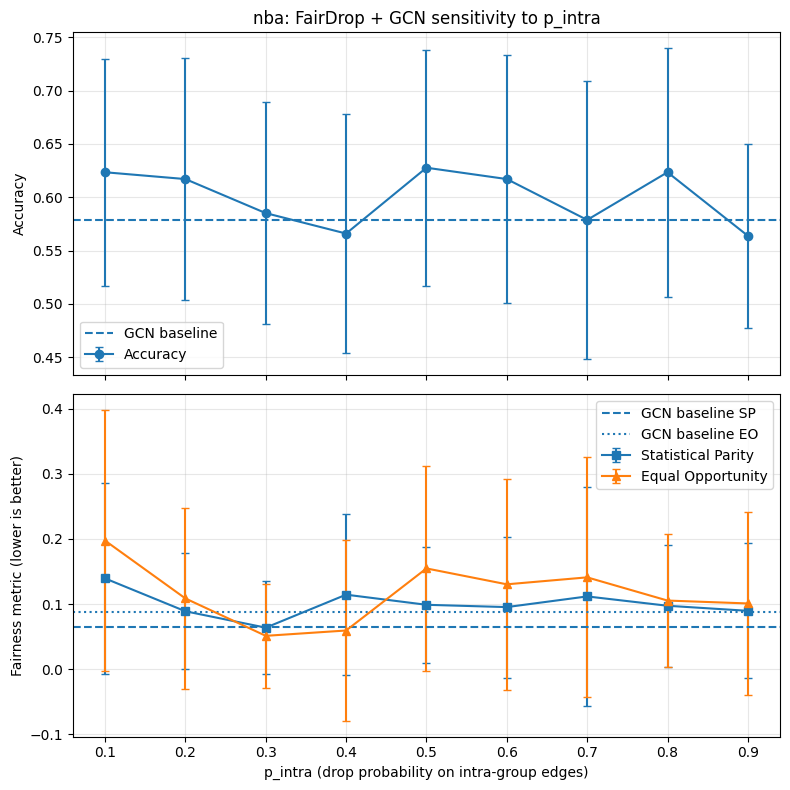

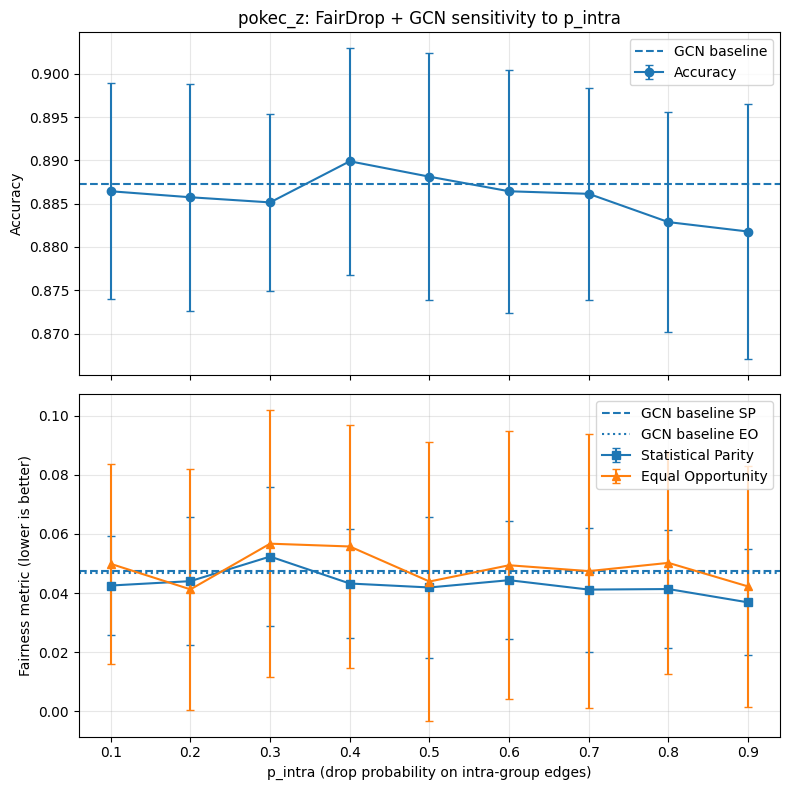

In [6]:
# =========================================================
# Extra Cell: FairDrop + GCN sweep on p_intra = 0.1 ... 0.9
# =========================================================

import matplotlib.pyplot as plt

P_INTRA_LIST = [round(x, 1) for x in np.arange(0.1, 1.0, 0.1)]
print("Sweep p_intra:", P_INTRA_LIST)

SWEEP_SAVE_DIR = os.path.join(SAVE_DIR, "fairdrop_p_intra_sweep")
os.makedirs(SWEEP_SAVE_DIR, exist_ok=True)


def run_fairdrop_sweep(data_dict, p_intra_list):

    all_dataset_results = {}

    for ds_name, data in data_dict.items():
        base_cfg = RUN_CONFIG[ds_name]
        dataset_rows = []

        print(f"\n{'='*70}")
        print(f"Running FairDrop + GCN sweep on {ds_name}")
        print(f"{'='*70}")

        for p_intra in p_intra_list:
            cfg = dict(base_cfg)
            cfg["fair_keep_same"] = 1.0 - p_intra   # drop prob -> keep prob
            cfg["fair_keep_diff"] = 1.0             # cross-group edges: no drop

            print(f"\n--- p_intra(drop) = {p_intra:.1f} | keep_same = {cfg['fair_keep_same']:.1f} ---")

            for seed in SEEDS:
                result = train_and_evaluate(
                    data=data,
                    cfg=cfg,
                    seed=seed,
                    use_fairdrop=True,
                    pretrained_encoder_state=None
                )

                row = {
                    "dataset": ds_name,
                    "p_intra": p_intra,
                    "seed": seed,
                    "accuracy": result["accuracy"],
                    "statistical_parity": result["statistical_parity"],
                    "equal_opportunity": result["equal_opportunity"],
                }
                dataset_rows.append(row)

                print(
                    f"seed={seed} | "
                    f"acc={row['accuracy']:.4f} | "
                    f"sp={row['statistical_parity']:.4f} | "
                    f"eo={row['equal_opportunity']:.4f}"
                )

        df = pd.DataFrame(dataset_rows)
        all_dataset_results[ds_name] = df

        # save raw per-seed results
        df.to_csv(
            os.path.join(SWEEP_SAVE_DIR, f"{ds_name}_fairdrop_p_intra_per_seed.csv"),
            index=False
        )

    return all_dataset_results


def summarize_fairdrop_sweep(all_dataset_results):

    summary_dict = {}

    for ds_name, df in all_dataset_results.items():
        summary = (
            df.groupby("p_intra")[["accuracy", "statistical_parity", "equal_opportunity"]]
            .agg(["mean", "std"])
            .reset_index()
        )

        # flatten columns
        summary.columns = [
            "p_intra",
            "acc_mean", "acc_std",
            "sp_mean", "sp_std",
            "eo_mean", "eo_std"
        ]

        summary_dict[ds_name] = summary
        summary.to_csv(
            os.path.join(SWEEP_SAVE_DIR, f"{ds_name}_fairdrop_p_intra_summary.csv"),
            index=False
        )

        print(f"\n===== Summary: {ds_name} =====")
        display(summary)

    return summary_dict


def plot_fairdrop_sweep(summary_dict, baseline_summary_df=None):

    for ds_name, summary in summary_dict.items():
        fig, axes = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

        x = summary["p_intra"].values

        # -------------------------
        # top: accuracy
        # -------------------------
        axes[0].errorbar(
            x, summary["acc_mean"], yerr=summary["acc_std"],
            marker="o", capsize=3, label="Accuracy"
        )
        axes[0].set_ylabel("Accuracy")
        axes[0].set_title(f"{ds_name}: FairDrop + GCN sensitivity to p_intra")
        axes[0].grid(True, alpha=0.3)

        # baseline horizontal line if available
        if baseline_summary_df is not None:
            row = baseline_summary_df[baseline_summary_df["dataset"] == ds_name]
            if len(row) > 0:
                acc_base = row["acc_mean"].values[0]
                axes[0].axhline(acc_base, linestyle="--", label="GCN baseline")
                axes[0].legend()

        # -------------------------
        # bottom: fairness metrics
        # -------------------------
        axes[1].errorbar(
            x, summary["sp_mean"], yerr=summary["sp_std"],
            marker="s", capsize=3, label="Statistical Parity"
        )
        axes[1].errorbar(
            x, summary["eo_mean"], yerr=summary["eo_std"],
            marker="^", capsize=3, label="Equal Opportunity"
        )

        # baseline fairness horizontal lines if available
        if baseline_summary_df is not None:
            row = baseline_summary_df[baseline_summary_df["dataset"] == ds_name]
            if len(row) > 0:
                sp_base = row["sp_mean"].values[0]
                eo_base = row["eo_mean"].values[0]
                axes[1].axhline(sp_base, linestyle="--", label="GCN baseline SP")
                axes[1].axhline(eo_base, linestyle=":", label="GCN baseline EO")

        axes[1].set_xlabel("p_intra (drop probability on intra-group edges)")
        axes[1].set_ylabel("Fairness metric (lower is better)")
        axes[1].grid(True, alpha=0.3)
        axes[1].legend()

        plt.tight_layout()
        plt.show()

        fig.savefig(
            os.path.join(SWEEP_SAVE_DIR, f"{ds_name}_fairdrop_p_intra_curve.png"),
            dpi=300,
            bbox_inches="tight"
        )


# -------------------------
# run sweep
# -------------------------
fairdrop_sweep_results = run_fairdrop_sweep(DATA_OBJECTS, P_INTRA_LIST)

# per-dataset summary
fairdrop_sweep_summary = summarize_fairdrop_sweep(fairdrop_sweep_results)

# plot curves
plot_fairdrop_sweep(
    summary_dict=fairdrop_sweep_summary,
    baseline_summary_df=baseline_summary if "baseline_summary" in globals() else None
)